### Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Data Preprocessing

In [3]:

# Load training data
train_csv_path = '/home/cadenug/ML Final Project/datasets/ashery/chexpert/versions/1/train.csv'
df = pd.read_csv(train_csv_path)

print("="*80)
print("CHEXPERT DATA EXPLORATION")
print("="*80)

# Total samples
print(f"\nTotal samples in train.csv: {len(df):,}")

# Filter to Frontal views only
df_frontal = df[df['Frontal/Lateral'] == 'Frontal'].copy()
print(f"Frontal views only: {len(df_frontal):,}")
print(f"   (Removed {len(df) - len(df_frontal):,} lateral views)")

# Your 5 selected diseases
SELECTED_DISEASES = [
    'Lung Opacity',
    'Pleural Effusion', 
    'Atelectasis',
    'Pneumothorax',
    'Pneumonia'
]

print(f"\Selected Diseases: {SELECTED_DISEASES}")

CHEXPERT DATA EXPLORATION

Total samples in train.csv: 223,414
Frontal views only: 191,027
   (Removed 32,387 lateral views)
\Selected Diseases: ['Lung Opacity', 'Pleural Effusion', 'Atelectasis', 'Pneumothorax', 'Pneumonia']


### Apply U-Zeros

In [ ]:

print("="*80)
print("APPLYING U-ZEROS STRATEGY (Replace -1.0 with 0.0)")
print("="*80)

# Count before U-Zeros
print("\nLabel Distribution BEFORE U-Zeros:")
print("\nDisease              | Positive | Negative | Uncertain | Blank")
print("-" * 70)
for disease in SELECTED_DISEASES:
    positive = (df_frontal[disease] == 1.0).sum()
    negative = (df_frontal[disease] == 0.0).sum()
    uncertain = (df_frontal[disease] == -1.0).sum()
    blank = df_frontal[disease].isna().sum()
    print(f"{disease:20} | {positive:8,} | {negative:8,} | {uncertain:9,} | {blank:5,}")

APPLYING U-ZEROS STRATEGY (Replace -1.0 with 0.0)

📈 Label Distribution BEFORE U-Zeros:

Disease              | Positive | Negative | Uncertain | Blank
----------------------------------------------------------------------
Lung Opacity         |   94,211 |    5,051 |     4,431 | 87,334
Pleural Effusion     |   76,899 |   25,299 |     9,578 | 79,251
Atelectasis          |   29,720 |    1,025 |    29,863 | 130,419
Pneumothorax         |   17,693 |   47,823 |     2,708 | 122,803
Pneumonia            |    4,675 |    1,875 |    15,981 | 168,496


In [6]:
# Apply U-Zeros transformation
for disease in SELECTED_DISEASES:
    df_frontal[disease] = df_frontal[disease].fillna(0.0)  # Blank → 0.0
    df_frontal[disease] = df_frontal[disease].replace(-1.0, 0.0)  # Uncertain → 0.0

# Count after U-Zeros
print("\nLabel Distribution AFTER U-Zeros:")
print("\nDisease              | Positive | Negative | % Positive | Imbalance Ratio")
print("-" * 80)
total_samples = len(df_frontal)
for disease in SELECTED_DISEASES:
    positive = (df_frontal[disease] == 1.0).sum()
    negative = (df_frontal[disease] == 0.0).sum()
    pct_positive = (positive / total_samples) * 100
    imbalance_ratio = negative / positive if positive > 0 else float('inf')
    print(f"{disease:20} | {positive:8,} | {negative:8,} | {pct_positive:9.2f}% | {imbalance_ratio:6.1f}:1")


Label Distribution AFTER U-Zeros:

Disease              | Positive | Negative | % Positive | Imbalance Ratio
--------------------------------------------------------------------------------
Lung Opacity         |   94,211 |   96,816 |     49.32% |    1.0:1
Pleural Effusion     |   76,899 |  114,128 |     40.26% |    1.5:1
Atelectasis          |   29,720 |  161,307 |     15.56% |    5.4:1
Pneumothorax         |   17,693 |  173,334 |      9.26% |    9.8:1
Pneumonia            |    4,675 |  186,352 |      2.45% |   39.9:1


### Multi-label Statistics

In [8]:
# Multi-label statistics
print("="*80)
print("MULTI-LABEL STATISTICS")
print("="*80)

# Count how many diseases per image
df_frontal['num_diseases'] = df_frontal[SELECTED_DISEASES].sum(axis=1)

print("\n📊 Number of diseases per image:")
print(df_frontal['num_diseases'].value_counts().sort_index())

print(f"\n📊 Average diseases per image: {df_frontal['num_diseases'].mean():.2f}")
print(f"📊 Max diseases in single image: {df_frontal['num_diseases'].max():.0f}")

MULTI-LABEL STATISTICS

📊 Number of diseases per image:
num_diseases
0.0    51981
1.0    67536
2.0    59526
3.0    11336
4.0      638
5.0       10
Name: count, dtype: int64

📊 Average diseases per image: 1.17
📊 Max diseases in single image: 5


### Co-corrence Matrix

In [9]:
# Co-occurrence matrix
print("="*80)
print("DISEASE CO-OCCURRENCE")
print("="*80)

co_occurrence = pd.DataFrame(index=SELECTED_DISEASES, columns=SELECTED_DISEASES, dtype=int)
for d1 in SELECTED_DISEASES:
    for d2 in SELECTED_DISEASES:
        both_positive = ((df_frontal[d1] == 1.0) & (df_frontal[d2] == 1.0)).sum()
        co_occurrence.loc[d1, d2] = both_positive

print("\nCo-occurrence Matrix (how many images have both diseases):")
print(co_occurrence)

DISEASE CO-OCCURRENCE

Co-occurrence Matrix (how many images have both diseases):
                  Lung Opacity  Pleural Effusion  Atelectasis  Pneumothorax  \
Lung Opacity           94211.0           47764.0      12625.0        8429.0   
Pleural Effusion       47764.0           76899.0      14589.0        5965.0   
Atelectasis            12625.0           14589.0      29720.0        2851.0   
Pneumothorax            8429.0            5965.0       2851.0       17693.0   
Pneumonia               3217.0            1396.0        500.0         126.0   

                  Pneumonia  
Lung Opacity         3217.0  
Pleural Effusion     1396.0  
Atelectasis           500.0  
Pneumothorax          126.0  
Pneumonia            4675.0  


### Visualization: Co-corrence Heatmap

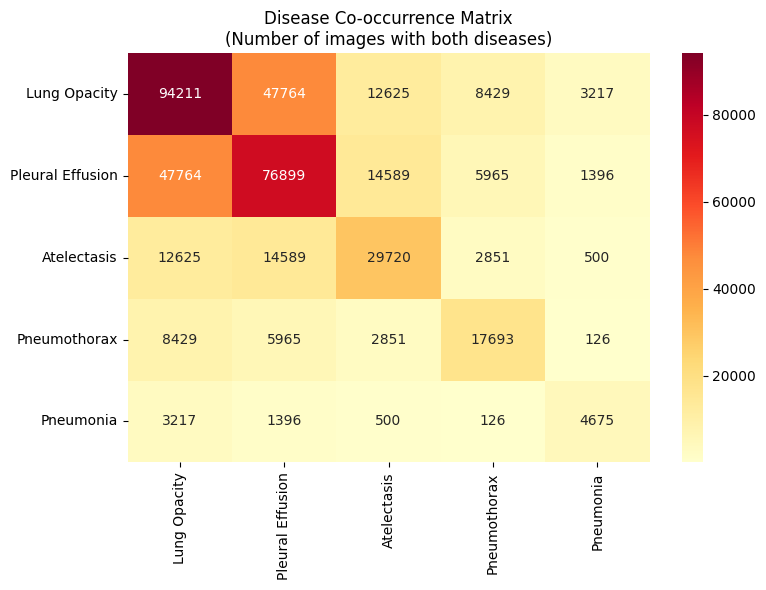

In [10]:
# Visualization: Co-occurrence heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(co_occurrence.astype(int), annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=SELECTED_DISEASES, yticklabels=SELECTED_DISEASES)
plt.title('Disease Co-occurrence Matrix\n(Number of images with both diseases)')
plt.tight_layout()
plt.show()

In [12]:
# Quick calculation from your co-occurrence diagonal
total_samples = 191027

diseases_positive = {
    'Lung Opacity': 94211,
    'Pleural Effusion': 76899,
    'Atelectasis': 29720,
    'Pneumothorax': 17693,
    'Pneumonia': 4675
}

print("Disease              | Positive | % Positive | Imbalance Ratio")
print("-" * 70)
for disease, pos_count in diseases_positive.items():
    pct = (pos_count / total_samples) * 100
    neg_count = total_samples - pos_count
    ratio = neg_count / pos_count
    print(f"{disease:20} | {pos_count:8,} | {pct:9.2f}% | {ratio:6.1f}:1")

Disease              | Positive | % Positive | Imbalance Ratio
----------------------------------------------------------------------
Lung Opacity         |   94,211 |     49.32% |    1.0:1
Pleural Effusion     |   76,899 |     40.26% |    1.5:1
Atelectasis          |   29,720 |     15.56% |    5.4:1
Pneumothorax         |   17,693 |      9.26% |    9.8:1
Pneumonia            |    4,675 |      2.45% |   39.9:1


### Calculate class weights for weighted BCE

In [ ]:
# Calculate class weights for weighted BCE
print("\nSuggested Class Weights (for Weighted BCE Loss):")
print("   (Inverse frequency, normalized)")
print("\nDisease              | Weight")
print("-" * 40)
for disease in SELECTED_DISEASES:
    positive = (df_frontal[disease] == 1.0).sum()
    weight = total_samples / (2 * positive) if positive > 0 else 1.0
    print(f"{disease:20} | {weight:.3f}")


⚖️  Suggested Class Weights (for Weighted BCE Loss):
   (Inverse frequency, normalized)

Disease              | Weight
----------------------------------------
Lung Opacity         | 1.014
Pleural Effusion     | 1.242
Atelectasis          | 3.214
Pneumothorax         | 5.398
Pneumonia            | 20.431


### Visualization: Class Distribution

/tmp/ipykernel_3910929/1754184897.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(SELECTED_DISEASES, rotation=45, ha='right')


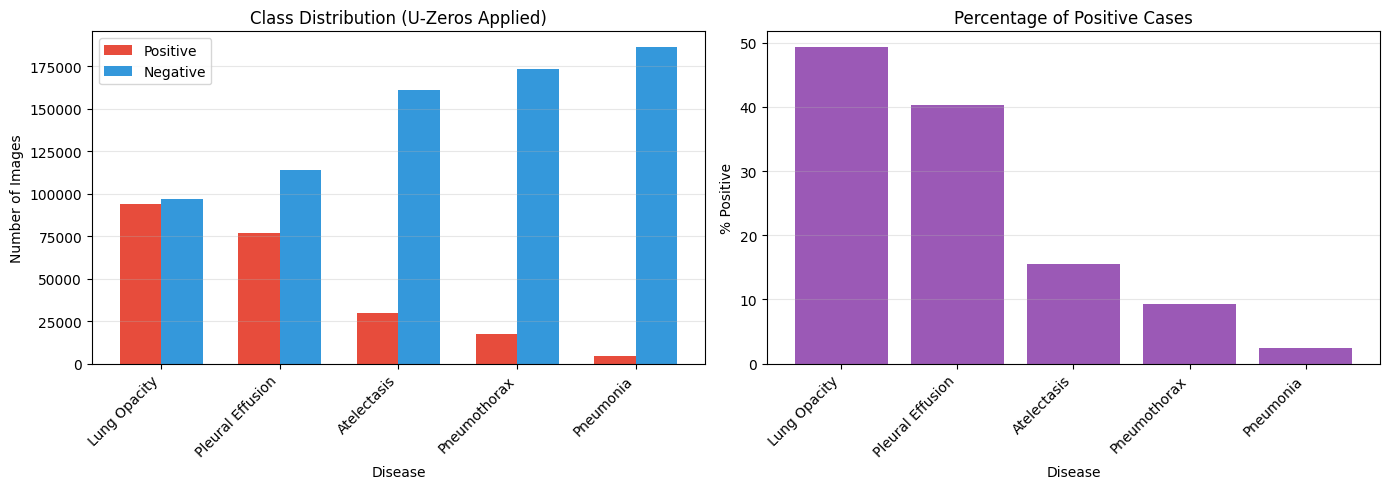

In [11]:
# Visualization: Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Positive vs Negative counts
positive_counts = [((df_frontal[d] == 1.0).sum()) for d in SELECTED_DISEASES]
negative_counts = [((df_frontal[d] == 0.0).sum()) for d in SELECTED_DISEASES]

x = np.arange(len(SELECTED_DISEASES))
width = 0.35

axes[0].bar(x - width/2, positive_counts, width, label='Positive', color='#e74c3c')
axes[0].bar(x + width/2, negative_counts, width, label='Negative', color='#3498db')
axes[0].set_xlabel('Disease')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Class Distribution (U-Zeros Applied)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(SELECTED_DISEASES, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Percentage positive
pct_positive = [(count / total_samples * 100) for count in positive_counts]
axes[1].bar(SELECTED_DISEASES, pct_positive, color='#9b59b6')
axes[1].set_xlabel('Disease')
axes[1].set_ylabel('% Positive')
axes[1].set_title('Percentage of Positive Cases')
axes[1].set_xticklabels(SELECTED_DISEASES, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()